In [ ]:
# ======================
# DOWNLOAD DATASET USING KAGGLEHUB
# ======================
import os
import kagglehub

# Download dataset
path = kagglehub.dataset_download("anandkumarsahu09/cattle-breeds-dataset")
print("Dataset downloaded to:", path)

# Construct dataset directory
DATA_DIR = os.path.join(path, "Cattle Breeds")
print("Using data from:", DATA_DIR)


100%|██████████| 20.9M/20.9M [00:00<00:00, 83.5MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/anandkumarsahu09/cattle-breeds-dataset/versions/1
Using data from: /root/.cache/kagglehub/datasets/anandkumarsahu09/cattle-breeds-dataset/versions/1/Cattle Breeds


100%|██████████| 20.9M/20.9M [00:00<00:00, 71.4MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/anandkumarsahu09/cattle-breeds-dataset/versions/1
Using data from: /root/.cache/kagglehub/datasets/anandkumarsahu09/cattle-breeds-dataset/versions/1/Cattle Breeds
Using device: cuda
Classes: ['Ayrshire cattle', 'Brown Swiss cattle', 'Holstein Friesian cattle', 'Jersey cattle', 'Red Dane cattle']
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


Epoch 01 | Train Acc = 47.25% | Val Acc = 77.31%
Epoch 02 | Train Acc = 73.26% | Val Acc = 88.24%
Epoch 03 | Train Acc = 83.11% | Val Acc = 90.76%
Epoch 04 | Train Acc = 87.98% | Val Acc = 93.28%
Epoch 05 | Train Acc = 91.71% | Val Acc = 94.12%
Epoch 06 | Train Acc = 91.40% | Val Acc = 96.64%
Epoch 07 | Train Acc = 93.68% | Val Acc = 94.96%
Epoch 08 | Train Acc = 94.61% | Val Acc = 94.96%
Epoch 09 | Train Acc = 95.44% | Val Acc = 93.28%
Epoch 10 | Train Acc = 95.44% | Val Acc = 94.96%
Epoch 11 | Train Acc = 94.30% | Val Acc = 94.96%
Epoch 12 | Train Acc = 93.68% | Val Acc = 95.80%
Epoch 13 | Train Acc = 95.34% | Val Acc = 94.96%
Epoch 14 | Train Acc = 95.75% | Val Acc = 96.64%
Epoch 15 | Train Acc = 95.54% | Val Acc = 96.64%
Epoch 16 | Train Acc = 95.65% | Val Acc = 96.64%
Epoch 17 | Train Acc = 94.82% | Val Acc = 97.48%
Epoch 18 | Train Acc = 95.54% | Val Acc = 97.48%
Epoch 19 | Train Acc = 95.34% | Val Acc = 95.80%
Epoch 20 | Train Acc = 95.65% | Val Acc = 96.64%
Epoch 21 | Train Acc

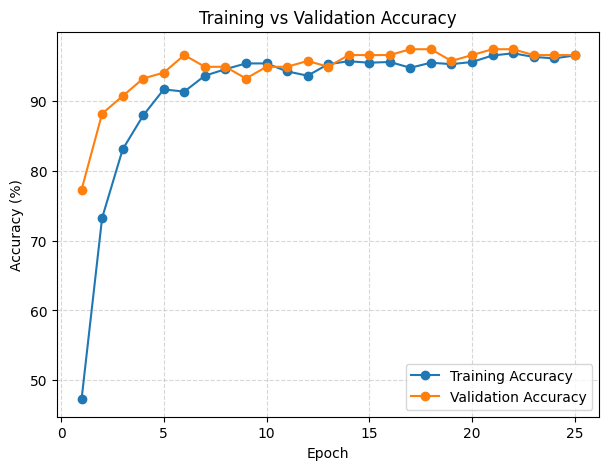

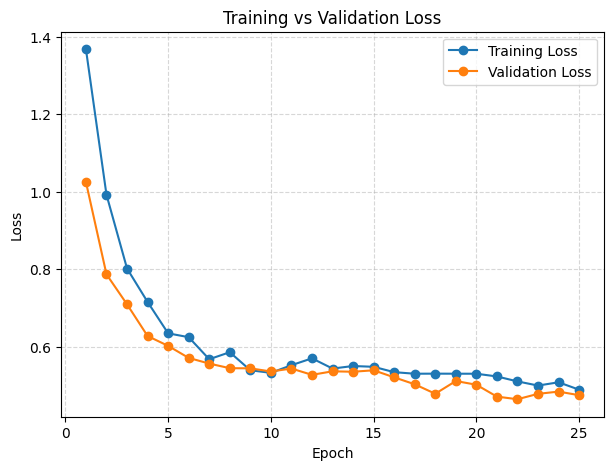


TEST REPORT:
                          precision    recall  f1-score   support

         Ayrshire cattle       0.96      1.00      0.98        26
      Brown Swiss cattle       1.00      1.00      1.00        25
Holstein Friesian cattle       0.89      0.96      0.93        26
           Jersey cattle       1.00      0.88      0.94        26
         Red Dane cattle       0.86      0.86      0.86        21

                accuracy                           0.94       124
               macro avg       0.94      0.94      0.94       124
            weighted avg       0.95      0.94      0.94       124



In [1]:
# ============================================================
# DOWNLOAD DATASET USING KAGGLEHUB
# ============================================================
import os
import kagglehub

path = kagglehub.dataset_download("anandkumarsahu09/cattle-breeds-dataset")
print("Dataset downloaded to:", path)

DATA_DIR = os.path.join(path, "Cattle Breeds")
print("Using data from:", DATA_DIR)

# ============================================================
# IMPORTS
# ============================================================
import random
import numpy as np
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# ============================================================
# LOAD DATASET
# ============================================================
base = datasets.ImageFolder(DATA_DIR, transform=test_transform)
class_names = base.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# TRAIN/VAL/TEST SPLIT
# ============================================================
def stratified_split(dataset):
    rng = np.random.default_rng(42)
    per_class = defaultdict(list)
    for i, (_, label) in enumerate(dataset.samples):
        per_class[label].append(i)

    train_idx, val_idx, test_idx = [], [], []
    for _, idxs in per_class.items():
        idxs = np.array(idxs)
        rng.shuffle(idxs)
        n = len(idxs)
        t = int(0.8 * n)
        v = int(0.1 * n)
        train_idx.extend(idxs[:t])
        val_idx.extend(idxs[t:t + v])
        test_idx.extend(idxs[t + v:])
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(base)

class SubsetWithTransform(Dataset):
    def __init__(self, base, idxs, transform):
        self.base = base
        self.idxs = idxs
        self.transform = transform

    def __len__(self): return len(self.idxs)

    def __getitem__(self, i):
        path, label = self.base.samples[self.idxs[i]]
        img = self.base.loader(path)
        return self.transform(img), label

train_ds = SubsetWithTransform(base, train_idx, train_transform)
val_ds   = SubsetWithTransform(base, val_idx, test_transform)
test_ds  = SubsetWithTransform(base, test_idx, test_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)

# ============================================================
# RESNET-50 MODEL
# ============================================================
class ResNetEnhanced(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        # Freeze first few layers
        for p in list(base.children())[:5]:
            for param in p.parameters():
                param.requires_grad = False

        in_dim = base.fc.in_features
        base.fc = nn.Identity()
        self.backbone = base

        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)

model = ResNetEnhanced(num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# ============================================================
# TRAINING — 25 EPOCHS
# ============================================================
train_acc_hist = []
val_acc_hist = []
train_loss_hist = []
val_loss_hist = []

def train(model, epochs=15):
    for ep in range(1, epochs + 1):
        model.train()
        total, correct, running_loss = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        v_correct, v_total, v_loss = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                v_loss += criterion(out, y).item()
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += y.size(0)

        val_acc = 100 * v_correct / v_total
        val_loss = v_loss / len(val_loader)
        scheduler.step()

        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)

        print(f"Epoch {ep:02d} | Train Acc = {train_acc:.2f}% | Val Acc = {val_acc:.2f}%")

    torch.save(model.state_dict(), "resnet50_final.pth")
    return model

# ============================================================
# TRAIN NOW (25 EPOCHS)
# ============================================================
model = train(model, 25)

# ============================================================
# GRAPHS
# ============================================================
epochs = range(1, len(train_acc_hist) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, train_acc_hist, marker='o', label='Training Accuracy')
plt.plot(epochs, val_acc_hist, marker='o', label='Validation Accuracy')
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, train_loss_hist, marker='o', label='Training Loss')
plt.plot(epochs, val_loss_hist, marker='o', label='Validation Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(); plt.show()

# ============================================================
# FINAL TEST RESULTS
# ============================================================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        all_preds.extend(model(x).argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

print("\nTEST REPORT:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Saving images.webp to images (1).webp
Image: images (1).webp

Predicted Breed: Brown Swiss cattle
Confidence: 0.8611002564430237


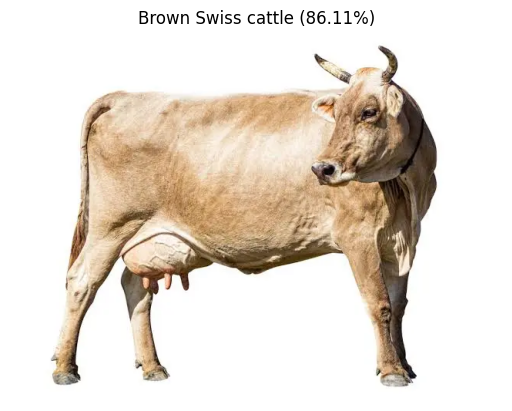

In [5]:
# ============================
# IMAGE PREDICTION (UPLOAD FILE)
# ============================

from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt   # <-- ADD THIS

uploaded = files.upload()  # Choose an image

for filename in uploaded.keys():
    img_path = filename
    print("Image:", img_path)

    # Load the image
    img = Image.open(img_path).convert("RGB")

    # Apply same preprocess as test dataset
    tfm = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485,0.456,0.406],
            [0.229,0.224,0.225],
        ),
    ])

    x = tfm(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        out = model(x)
        prob = torch.softmax(out, dim=1)[0]
        pred_idx = prob.argmax().item()

    print("\nPredicted Breed:", class_names[pred_idx])
    print("Confidence:", float(prob[pred_idx]))

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_names[pred_idx]} ({prob[pred_idx]*100:.2f}%)")
    plt.show()
